In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

student = pd.read_csv('student-mat.csv')

df = pd.DataFrame(student)  

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## DATA DISTRIBUTION EDA

C:\Users\asus\AppData\Local\Temp\ipykernel_19032\1713329785.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:olive'` for the same effect.

  sns.boxplot(data=df,x=df['address'],y=df['G3'],ax=axes[1,0],hue='sex',color='olive')


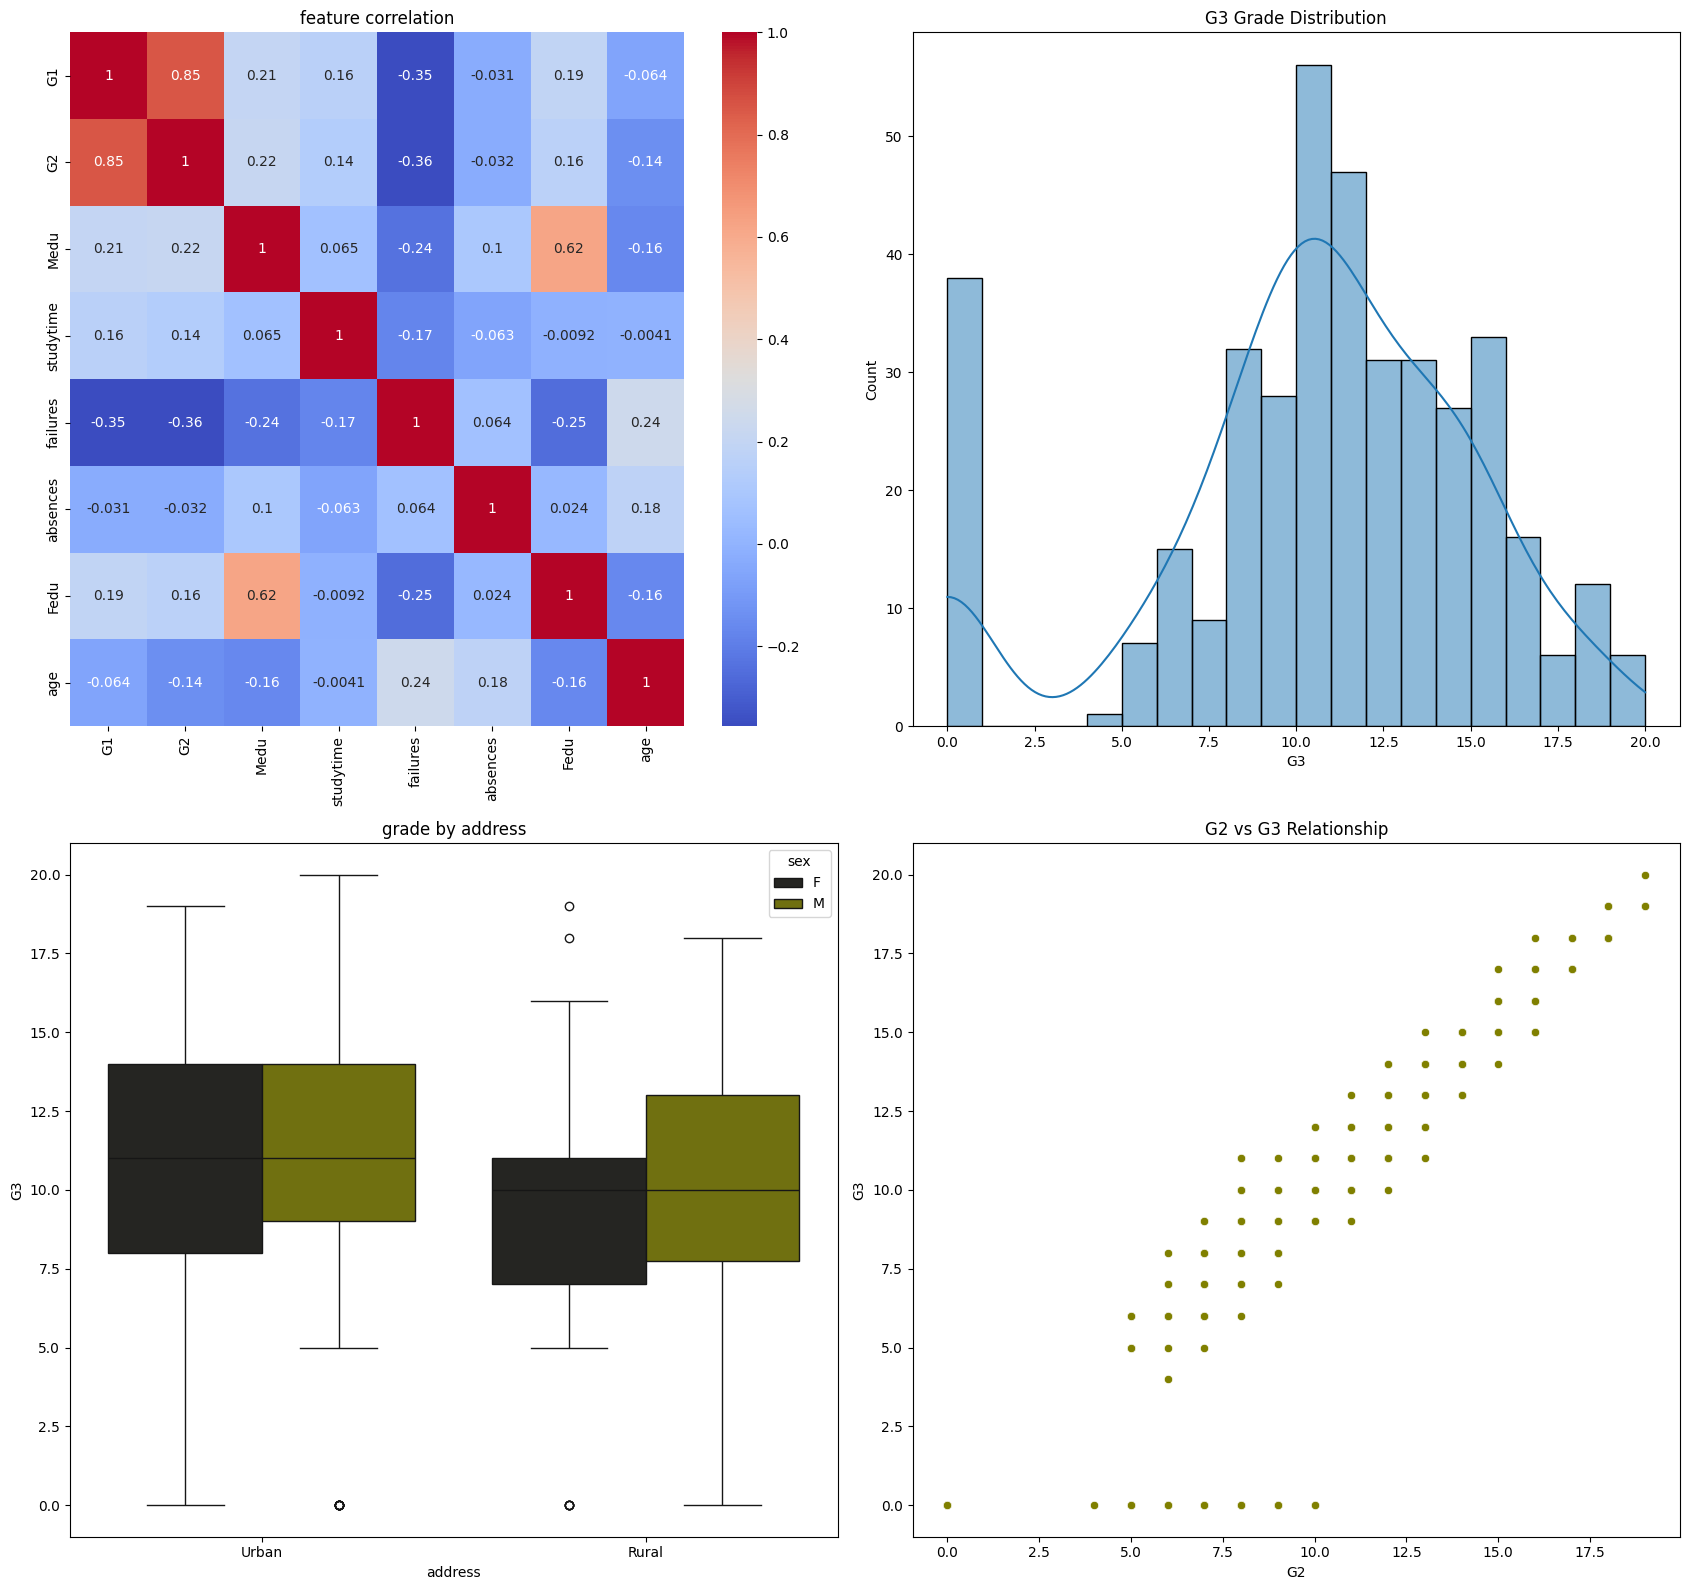

In [ ]:
fig, axes = plt.subplots(2,2,figsize= (17,16))
sns.heatmap(data=df[['G1', 'G2', 'Medu', 'studytime', 'failures', 'absences', 'Fedu', 'age']].corr(),annot=True,cmap='coolwarm',ax=axes[0,0])
axes[0,0].set_title('feature correlation')

sns.histplot(df['G3'],bins=20,ax=axes[0,1],kde=True)
axes[0,1].set_title('G3 Grade Distribution')

sns.boxplot(data=df,x=df['address'],y=df['G3'],ax=axes[1,0],hue='sex',color='olive')
axes[1,0].set_xticks([0,1],labels=['Urban','Rural'])
axes[1,0].set_title('grade by address')

sns.scatterplot(data=df,x=df['G2'],y=df['G3'],color='olive')
axes[1,1].set_title('G2 vs G3 Relationship')
plt.tight_layout()
plt.show()

## DATA RELATIONSHIP EDA


Text(0.5, 1.0, 'How Many Students Got Each Grade')

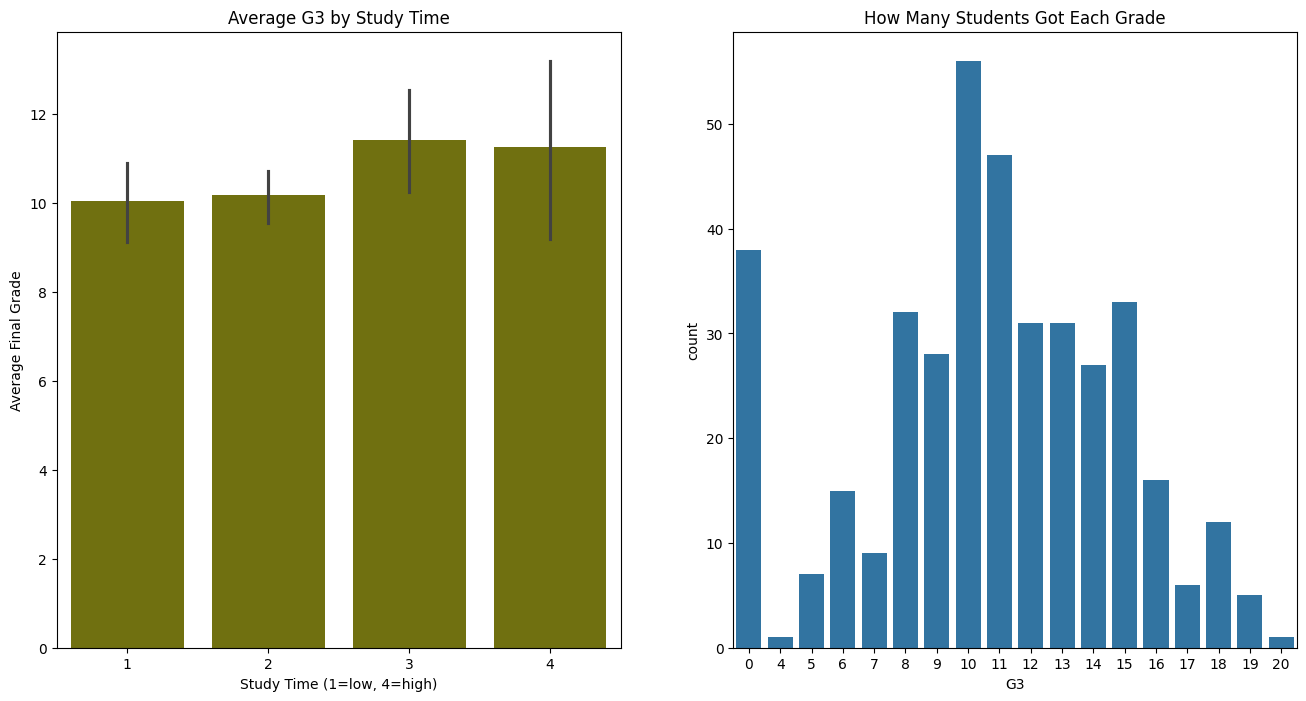

In [68]:
fig,axes = plt.subplots(1,2,figsize=(16,8))

sns.barplot(data=df,x=df['studytime'],y=df['G3'],color='olive',ax=axes[0])
axes[0].set_title('Average G3 by Study Time')
axes[0].set_xlabel('Study Time (1=low, 4=high)')
axes[0].set_ylabel('Average Final Grade')

sns.countplot(data=df, x=df['G3'], ax=axes[1])
axes[1].set_title('How Many Students Got Each Grade')

#### heatmap: G1 and G2 have the strongest correlation with each other at 0.85 showing that students who perform well in first period tend to perform well in second period too. Failures show negative correlation with G1 and G2 meaning more failures leads to lower grades. Medu and Fedu show 0.62 correlation meaning educated mothers tend to have educated fathers too.

#### histogram: Most students scored between 10 and 12 in their final grade. 38 students scored 0 which likely represents dropouts or students who did not appear for the exam. The distribution is slightly left skewed meaning fewer students scored very high grades.

#### boxplot: Urban students have a slightly higher median grade of around 11 compared to rural students at 10. Urban students also show one outlier at 0 meaning at least one urban student completely failed or dropped out. Overall location has a small but visible effect on final grade.

#### scatterplot: There is a clear positive linear relationship between G2 and G3. Students with higher second period grades almost always score higher in their final grade. This confirms why G2 was chosen as one of the most important features in our prediction model. The few dots at G3=0 despite having G2 scores suggest some students dropped out before the final exam.

#### barplot: Students who study more hours per week tend to score slightly higher final grades on average. Study time 3 shows the highest average grade at around 11.4 while study time 1 and 2 both average around 10. Interestingly study time 4 does not score higher than study time 3 which suggests that after a certain point more study hours do not guarantee better grades. The error bars show there is high variation within each group meaning study time alone is not the only factor affecting final grade.

#### countplot: Grade 10 is the most common final grade with 57 students. Grades between 8 and 15 cover the majority of students. Grade 0 has 38 students which is unusually high and represents students who either dropped out or did not appear for the final exam. Very few students scored above 18 showing high grades are rare.